# Simulation of Multi-mode Interferometer

## Step 0: Open the Lumerical MODE session

In [1]:
%load_ext autoreload
%autoreload 2
# Remember to remove the lines after
import lumapi
import numpy as np
import matplotlib.pyplot as plt

from functools import partial
from IPython.display import display



# Open the session and build the first geometry (edit the build_geometry.lsf script)
sim = lumapi.MODE()

## Step 1: Create the geometry

Define the geometry function and set the default parameters.
> Edit this script to customize the geometry


This example uses a `Anti-Symmetric` boundary condition on the lower simulation edge instead of
building both halves of the 1x2 splitter. A symmetric-interference 1x2 MMI only excites even
modes, so the field is mirror-symmetric about the input waveguide axis; simulating just the upper
half with an anti-symmetric wall reproduces the full device at a fraction of the mode count and
compute cost.

In [28]:
import lumapi_util as lu

sim.switchtolayout()
sim.deleteall()

# Define the parameters

default_params = {
    "w_wg": 0.53,
    # "w_ap": 2,
    "w_mmi": 5,
    "t_wg": 0.15,
    "ln_mmi": 10,
    "ln_taper": 0.5,
    "n_points": 22,
    # "s_wg": 2.5,
    "sidewall_angle": 90,
    "layers": ["WG"],
    "wavelength": 1.55,
    # "port_size": (4, 3),
    "n_modes": 15,
    "n_cells": 1,
    "bc": ["Anti-Symmetric", "PML", "PML", "PML"]
    }

from lumapi_util.paths import STACK_DATA_DIR

stack_file = STACK_DATA_DIR / "sample_soi.lbr"
stack_length = 40

# Layer stack made far larger than any device so its extent never needs to track geometry length
# (the mesh override region below stays sized to stack_length, so this costs nothing extra).
stack_extent = 1000
lu.add_layerstack_fromfile(sim, filename=stack_file.as_posix(), size=[stack_extent, 200, None], center=[0, 0, 0])



# Create a mod geometry specific for the problem
def mod_geometry(sim, **params):
    params = {**default_params, **params}

    wavelength=params.get("wavelength", 1.55)

    sim.switchtolayout()

    
    # Create the geometries for the MMI
    sim.setnamed("layer group", "geometry", {})  # Reset

    left_ext = 2
    taper_ln = params["ln_taper"]
    mmi_ln = params["ln_mmi"]
    mmi_width = params["w_mmi"]
    wg_spacing = params.get("s_wg", mmi_width / 2)
    wg_width = params["w_wg"]
    ap_width = params.get("w_ap", wg_width)
    

    # No taper: the aperture section is a straight guide at the final aperture width, since the
    # single-cell EME approximation below cannot resolve a continuously-varying taper anyway. This
    # isolates the MMI's sensitivity to aperture width from any taper transition effects (a separate
    # taper transition can be simulated independently and its S-matrix cascaded with this result).
    aperture_wg = lu.straight_waveguide(left_ext + taper_ln, ap_width)
    mmi_wg = lu.straight_waveguide(mmi_ln, mmi_width)

    geometries = [
                aperture_wg + np.array([0, 0]), 
                mmi_wg + np.array([left_ext + taper_ln, 0]),
                lu.rotate(aperture_wg, 180) + np.array([2 * left_ext + 2 * taper_ln + mmi_ln, wg_spacing/2]),
                lu.rotate(aperture_wg, 180) + np.array([2 * left_ext + 2 * taper_ln + mmi_ln, -wg_spacing/2]),
                ]


    # Put the geometries in the layers
    layers = params.get("layers", ["WG"])

    # To set the thickness, use sparingly
    if t := params.get("t") is not None:
        sim.select("layer group")
        sim.setlayer(layers[0], "thickness", t * 1e-6)

    
    for layer in layers:

        sim.select("layer group")
        sim.setlayer(layer, "sidewall angle", params.get("sidewall_angle", 90))
        lu.set_geometries_to_layer(sim, geometries=geometries, layer=layer)

    # Set up the EME
    
    wg_info = lu.get_layer_info(sim, layers[0])
    zc = wg_info["z0"] + wg_info["t"]/2
    n_cells = params.get("n_cells", 20)
    if n_cells > 1:
        eme_cells = [(1, 1.), (n_cells, taper_ln), (1, mmi_ln), (n_cells, taper_ln), (1, 1.)]
    else:
        eme_cells = [(1, taper_ln + 1.), (1, mmi_ln), (1, taper_ln + 1.)]

    sim_width = params.get("sim_width", mmi_width + 3)

    lu.define_eme(sim, 
                  wavelength=wavelength, 
                  size=[None, sim_width, 3.], 
                  center=[1., 0., zc], 
                  cells=eme_cells, 
                  bc=params.get("bc", ["Metal"] * 4), 
                  n_modes=params.get("n_modes", 10))

    # Define meshing
    lu.define_mesh(sim, name="mesh_struct", size=[stack_length, params["w_mmi"], 0.2], center=[stack_length/2, 0., zc], steps=[None, wavelength / 20, wavelength / 20])
    
    # Define profiles
    lu.define_eme_profile(sim, size=[60, 20, None], center=[30., 0., zc])

    # Define ports
    # port_size = params["port_size"]
    # lu.define_eme_port(sim, port_number=1, size=[None, *port_size], location="left")
    # lu.define_eme_port(sim, port_number=2, size=[None, *port_size], center=[None, wg_spacing/2, 0], location="right")
    




mod_geometry(sim, wi=0.6, sidewall_angle=90)

[ensure_object] 'EME' not found. Creating a new 'EME'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...
[ensure_object] 'profile z-normal' not found. Creating a new 'emeprofile'...


## General theory of multi-mode interferometer


Reference: **"Optical Multi-Mode Interference Devices Based on Self-Imaging: Principles and Applications"** by Soldano and Pennings (1995) 

---

### **Key Concepts**

1. **Self-Imaging Principle**:

   * In multimode waveguides, an input field can reproduce itself (or its mirrored/multiple images) at specific intervals along the propagation direction due to **constructive interference** between supported modes.

2. **Three Main Interference Mechanisms**:

   * **General Interference**: No restrictions on mode excitation.
   * **Paired Interference**: Only specific modes (e.g., v = 2, 5, 8...) are excited.
   * **Symmetric Interference**: Only even symmetric modes are excited.

---

### **Important Equations**

#### 1. **Waveguide Mode Propagation Constants**

Given a step-index multimode waveguide:

$$
k_0^2 n_r^2 = k_{y,v}^2 + \beta_v^2 \tag{1}
$$

$$
k_{y,v} = \frac{(v+1)\pi}{W_{\text{eff}}} \tag{2}
$$

$$
\beta_v \approx k_0 n_r \left[1 - \frac{1}{2} \left( \frac{(v+1)\lambda_0}{2n_r W_{\text{eff}}} \right)^2 \right] \tag{3}
$$

Where:

* $\beta_v$: Propagation constant of the v-th mode.
* $W_{\text{eff}}$: Effective width of the multimode region.
* $n_r$: Effective index of the waveguide core.
* $k_0 = \frac{2\pi}{\lambda_0}$: Free-space wavenumber.

---

#### 2. **Beat Length Between Fundamental Modes**

$$
L_\pi = \frac{\pi}{\beta_0 - \beta_1} \approx \frac{4n_r W_{\text{eff}}^2}{3\lambda_0} \tag{4}
$$

This length defines the periodicity of self-imaging.
One could express the beat length using the *effective indices* that are found by simulation

$$
L_\pi = \frac{\lambda_0 / 2}{n_{eff,0} - n_{eff,1}} 
$$

---

#### 3. **Field Expansion and Propagation**

Input field decomposition:

$$
\phi(y, 0) = \sum_{v=0}^{m-1} c_v \psi_v(y) \tag{5}
$$

Field after propagation distance $z$:

$$
\phi(y, z) = \sum_{v=0}^{m-1} c_v \psi_v(y) e^{-j\beta_v z} \tag{6}
$$

---

#### 4. **Imaging Conditions**

Self-imaging occurs when phase differences satisfy:

* **Direct Image**: $\beta_0 - \beta_v = \frac{2\pi p_v}{L}$
* **Mirrored Image**: Even/odd modes in anti-phase.

#### Beat Length for **General Interference** (for any N)

$$
L = p(3L_\pi),\quad p \in \mathbb{Z} \tag{7}
$$

For N-fold images (general case):

$$
L = \frac{p}{N}(3L_\pi),\quad \text{gcd}(p,N)=1 \tag{8}
$$



#### Beat Length for **Symmetric Interference** (for 1xN, especially 1x2)

In symmetric interference, **only even symmetric modes** are excited: $v = 0, 2, 4, \dots$.

Because of this restriction, the **periodicity of phase accumulation reduces by a factor of 4**. Therefore:


$$
L = \frac{p}{N}\left(\frac{3L_\pi}{4}\right),\quad p \in \mathbb{Z} \tag{8}
$$

In particular, for the first order $p=1$ and for 1x2 splitter we have:
$$
L = \frac{3}{8}L_\pi \tag{9}
$$

The input location must be at
$$
y = 0
$$

whereas the output must be at
$$
y = \pm \frac{W_{\text{eff}}}{4} 
$$


####  Beat Length for **Paired Interference** (for 2xN, especially 2x2)

In paired interference, **only modes with $v = 0, 1, 3, 4, 6, 7, \dots$** are excited (i.e., excluding $v = 2, 5, 8, \dots$).

This results in a **tripled periodicity** due to repeating structure in $v(v + 2) \mod 3$. Hence:

$$
L = p\left(L_\pi\right),\quad p \in \mathbb{Z} \tag{7}
$$

For N-fold images (general case):

$$
L = \frac{p}{N}\left(L_\pi\right),\quad p \in \mathbb{Z} \tag{8}
$$

The input and the output locations must be at
$$
y = \pm \frac{W_{\text{eff}}}{6} 
$$


---

#### 5. **Phase Relation in N×N MMI Couplers**

The relative output phase for inputs T and outputs s:

* For $T + s$ even:

$$
\phi_{rs} = \frac{\pi}{4N}(s-1)(2N + T - s) + \pi \tag{11}
$$

* For $T + s$ odd:

$$
\phi_{rs} = -\frac{\pi}{4N}(r + s - 1)(2N - T - s + 1) \tag{12}
$$

---






In [3]:
import pandas as pd
import numpy as np

# --- Analytical Model:  ---
def effective_width_model(W_um, lambda_0_um, n_core, n_clad):
    delta = (lambda_0_um / (2 * np.pi)) / np.sqrt(n_core**2 - n_clad**2)
    return W_um + 2 * delta

def lpi_from_effective_width_model(n_r, n_core, n_clad, W_um):
    """
    Returns a function L_pi_model(lambda_0) that uses effective width approximation.
    """
    def model(lambda_0_um):
        W_eff = effective_width_model(W_um, lambda_0_um, n_core, n_clad)
        return (4 * n_r * W_eff**2) / (3 * lambda_0_um)
    return model

# --- Simulation-based Model ---
def lpi_from_simulation(n0, n1):
    """
    Returns a function L_pi_model(lambda_0) using simulated effective indices.
    """
    def model(lambda_0_um):
        return lambda_0_um / (2 * (n0 - n1))
    return model

# --- Core Function ---
def compute_mmi_lengths(lambda_0_um, L_pi_model):
    """
    Compute MMI lengths given only lambda_0 and an L_pi model function.
    
    Parameters:
    - lambda_0_um: wavelength in microns
    - L_pi_model: function that takes lambda_0 and returns L_pi
    
    Returns:
    - DataFrame of MMI imaging lengths.
    """
    L_pi = L_pi_model(lambda_0_um)

    # Derived lengths
    lengths = {
        "L_pi (model output)": L_pi,
        "1x2 imaging (symmetric)": 3 * L_pi / 8,
        "2x2 3dB (general)": 1.5 * L_pi,
        "2x2 cross (general)": 3 * L_pi,
        "2x2 3dB (paired)": 0.5 * L_pi,
        "2x2 cross (paired)": L_pi,
        
    }

    df = pd.DataFrame({
        "Parameter": list(lengths.keys()),
        "Length (µm)": [round(val, 3) for val in lengths.values()]
    })

    return df




In [4]:
from functools import partial

# Si core / SiO2 clad, matching the 1550 nm SOI example below (w_mmi=2.5)
compute_mmi_lengths(1.55, 
                    lpi_from_effective_width_model(2.4, 3.47, 1.44, 2.5)
                    )

,Parameter,Length (µm)
0,L_pi (model output),14.567
1,1x2 imaging (symmetric),5.463
2,2x2 3dB (general),21.850
3,2x2 cross (general),43.700
4,2x2 3dB (paired),7.283
5,2x2 cross (paired),14.567


## Function for sweeps

In [12]:
# Define functions for sweeps

def compute_excess_loss(sim):
    S = lu.run_eme_propagation(sim)
    P = 2 * lu.lin2db(S)
    return -P[1, 0]

def set_wavelength_analysis(sim, wavelength):
    sim.setemeanalysis("override wavelength", True)
    sim.setemeanalysis("wavelength", wavelength * 1e-6)


def compute_excess_loss_from_start(sim, mmi_length=9, wavelength=None):
    lu.run_eme(sim, "mmi1x2_sweep.lms")
    lu.set_eme_group_lengths(sim, 1, mmi_length)  # Set the value you found in the previous sim
    if wavelength is not None:
        set_wavelength_analysis(sim, wavelength=wavelength)

    return compute_excess_loss(sim)


def mmi_length_sweep(sim, lengths=None, filename=None):
    if lengths is None:
        lengths = np.arange(2, 30, 0.1)

    filename = filename or f"mmi1x2_length_sweep.csv"

    EL, summary = lu.sweep_param_result(
            sim,
            sweep_params={"lengths": lengths},
            geometry_params={"cell_range": 1},
            geometry_fn=lu.set_eme_group_lengths,
            result_fn=compute_excess_loss,
            result_type=float,
            save_path=filename
        )


    lu.plot_metric_1d({"length": lengths}, EL, x_param="length", metric_name="Excess Loss")
    return summary


def aperture_width_sweep(sim, widths, params, mmi_length=9, filename=None):
    filename = filename or f"mmi1x2_ap_width_sweep.csv"

    EL, summary = lu.sweep_param_result(
            sim,
            sweep_params={"w_ap": widths},
            geometry_fn=mod_geometry,
            geometry_params=params,
            result_fn=compute_excess_loss_from_start,
            result_params={"mmi_length": mmi_length},
            result_type=float,
            save_path=filename
        )

    lu.plot_metric_1d({"w_ap": widths}, EL, x_param="w_ap", metric_name="Excess loss")
    return summary




def wavelength_sweep(sim, wl):
    
    EL, summary = lu.sweep_param_result(
            sim,
            sweep_params={"wavelength": wl},
            geometry_fn=set_wavelength_analysis,
            result_fn=compute_excess_loss,
            result_type=float,
            save_path="wavelength_sweep.csv"
        )

    sim.setemeanalysis("override wavelength", False)


    lu.plot_metric_1d({"wavelength": wl}, EL, x_param="wavelength", metric_name="Excess loss")
    return summary


def get_best_param(df: pd.DataFrame, param_col, default=10, col='result'):
    if df.empty:
        return default

    min_idx = df[col].idxmin()  # index of first minimum
    if pd.isna(min_idx):
        return default

    return df.loc[min_idx, param_col]



# Actual Simulation MMI1x2

In [17]:
device_name = "mmi1x2_1550nm"

mmi_params = dict(
    layers=["WG"],
    wavelength=1.55,
    w_wg=0.5,
    w_mmi=2.5,
    ln_mmi=5.5,  # initial guess from the analytical model above; refined by the sweep below
)

mod_geometry(sim, **mmi_params)

In [18]:
lu.run_eme(sim, "mmi1x2")

100%|██████████| 100/100 [00:12<00:00,  7.70it/s, parameters=lengths=7.949999999999982]


✅ Sweep completed. Results saved to: mmi1x2_1550nm.csv


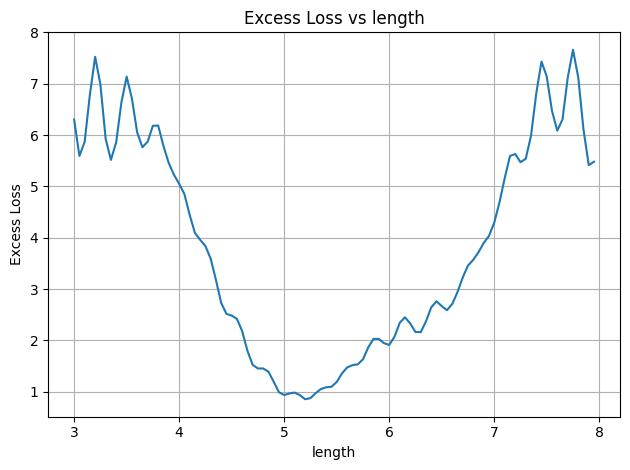

np.float64(5.199999999999992)

In [19]:

lengths = np.arange(3, 8, 0.05)

def mmi_length_sweep(sim, lengths):
    EL, summary = lu.sweep_param_result(
            sim,
            sweep_params={"lengths": lengths},
            geometry_params={"cell_range": 1},
            geometry_fn=lu.set_eme_group_lengths,
            result_fn=compute_excess_loss,
            result_type=float,
            save_path=f"{device_name}.csv"
        )


    lu.plot_metric_1d({"length": lengths}, EL, x_param="length", metric_name="Excess Loss")
    return summary

summary = mmi_length_sweep(sim, lengths=lengths)
best_length = get_best_param(summary, param_col="lengths", default=5.5, col="result")
best_length

100%|██████████| 21/21 [00:02<00:00,  7.28it/s, parameters=wavelength=1.5999999999999979]


✅ Sweep completed. Results saved to: wavelength_sweep.csv


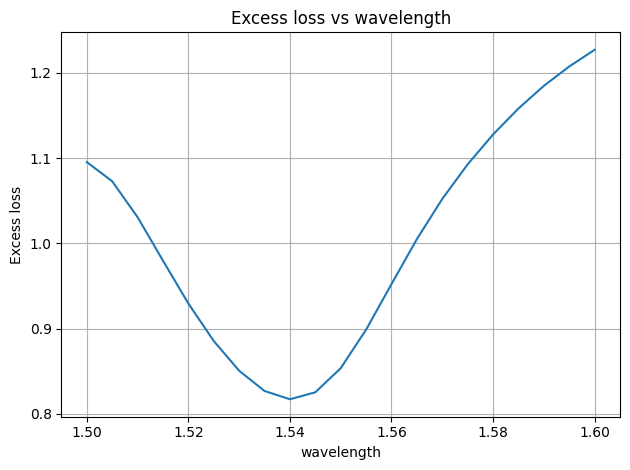

,wavelength,result
0,1.500,1.095502
1,1.505,1.072976
2,1.510,1.030845
3,1.515,0.979861
4,1.520,0.929592
5,1.525,0.885618
6,1.530,0.850730
7,1.535,0.826996
8,1.540,0.817290
9,1.545,0.825434


In [14]:
lu.set_eme_group_lengths(sim, 1, best_length)

def mod_wavelength_analysis(sim, wavelength):
    sim.setemeanalysis("override wavelength", True)
    sim.setemeanalysis("wavelength", wavelength * 1e-6)

def wavelength_sweep(sim, wl):
    
    EL, summary = lu.sweep_param_result(
            sim,
            sweep_params={"wavelength": wl},
            geometry_fn=mod_wavelength_analysis,
            result_fn=compute_excess_loss,
            result_type=float,
            save_path="wavelength_sweep.csv"
        )

    sim.setemeanalysis("override wavelength", False)


    lu.plot_metric_1d({"wavelength": wl}, EL, x_param="wavelength", metric_name="Excess loss")
    return summary

wavelengths = np.arange(1.5, 1.6, 0.005)
wavelength_sweep(sim, wavelengths)


## Aperture width sweep

The taper's near-MMI facing width (`w_ap`) is a separate parameter from the bus waveguide width
(`w_wg`) and can be tuned independently to improve mode matching into the multimode section.


100%|██████████| 10/10 [39:35<00:00, 237.59s/it, parameters=w_ap=1.2]               


✅ Sweep completed. Results saved to: mmi1x2_ap_width_sweep.csv


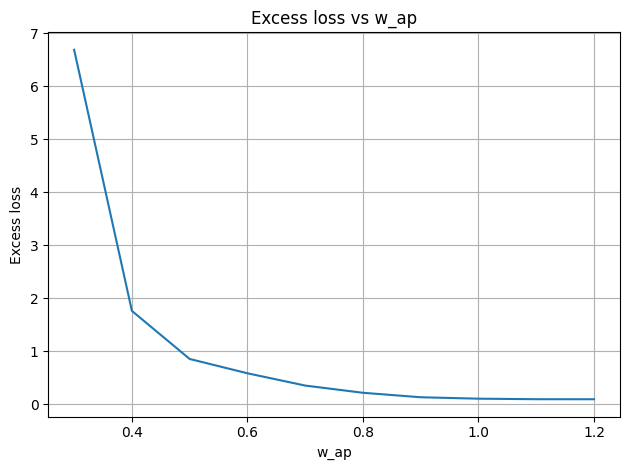

np.float64(1.2)

In [21]:
ap_widths = np.linspace(0.3, 1.2, 10)

ap_summary = aperture_width_sweep(
    sim,
    widths=ap_widths,
    params={**mmi_params, "ln_mmi": best_length},
    mmi_length=best_length,
)
best_ap_width = get_best_param(ap_summary, param_col="w_ap", default=mmi_params["w_wg"], col="result")
best_ap_width

## Final result

Wavelength response of the optimized design (the sweep above already left the geometry at
`w_ap = best_ap_width`, so no rebuild is needed here).

100%|██████████| 21/21 [00:06<00:00,  3.19it/s, parameters=wavelength=1.5999999999999979]


✅ Sweep completed. Results saved to: mmi1x2_1550nm_final_wavelength_sweep.csv


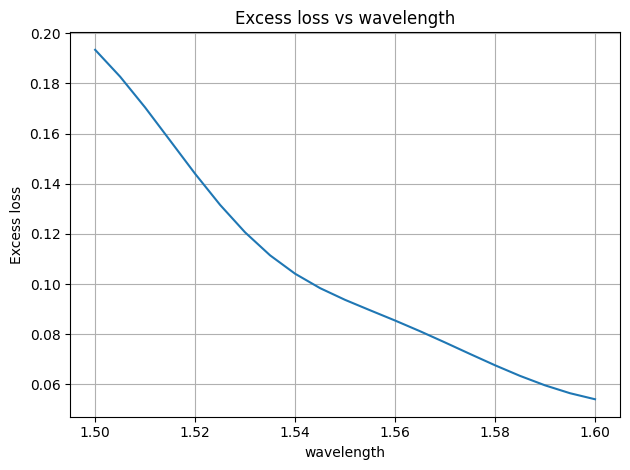

,wavelength,result
0,1.500,0.193411
1,1.505,0.182696
2,1.510,0.170424
3,1.515,0.157219
4,1.520,0.143989
5,1.525,0.131584
6,1.530,0.120631
7,1.535,0.111474
8,1.540,0.104151
9,1.545,0.098400


In [22]:
final_wavelengths = np.arange(1.5, 1.6, 0.005)

EL, final_summary = lu.sweep_param_result(
        sim,
        sweep_params={"wavelength": final_wavelengths},
        geometry_fn=set_wavelength_analysis,
        result_fn=compute_excess_loss,
        result_type=float,
        save_path=f"{device_name}_final_wavelength_sweep.csv"
    )

sim.setemeanalysis("override wavelength", False)

lu.plot_metric_1d({"wavelength": final_wavelengths}, EL, x_param="wavelength", metric_name="Excess loss")
final_summary

## MMI length sensitivity check

Set `L = 5.4 µm` (vs. the optimum `best_length ≈ 5.2 µm`) and re-run the wavelength sweep to see
whether the excess-loss minimum shifts in wavelength.

100%|██████████| 21/21 [00:05<00:00,  4.09it/s, parameters=wavelength=1.5999999999999979]


✅ Sweep completed. Results saved to: mmi1x2_1550nm_L5.4_wavelength_sweep.csv


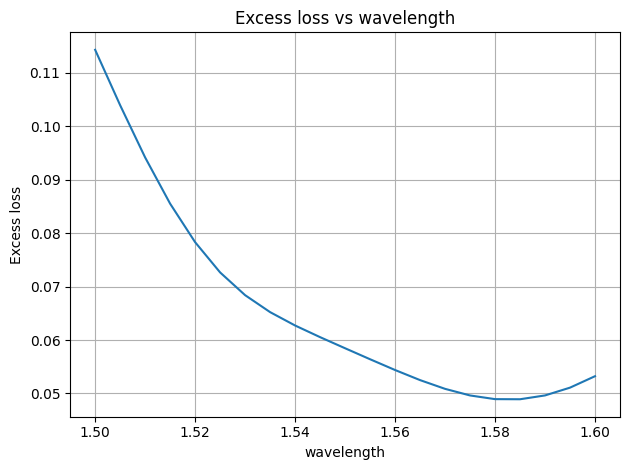

L=5.2 minimum at: 1.5999999999999979
L=5.4 minimum at: 1.5849999999999982


In [23]:
# Reuses the modes already solved for by the last sim.run(); only propagation is redone per point.
lu.set_eme_group_lengths(sim, 1, 5.4)

EL_L54, summary_L54 = lu.sweep_param_result(
        sim,
        sweep_params={"wavelength": final_wavelengths},
        geometry_fn=set_wavelength_analysis,
        result_fn=compute_excess_loss,
        result_type=float,
        save_path=f"{device_name}_L5.4_wavelength_sweep.csv"
    )

sim.setemeanalysis("override wavelength", False)

lu.plot_metric_1d({"wavelength": final_wavelengths}, EL_L54, x_param="wavelength", metric_name="Excess loss")

print("L=5.2 minimum at:", final_summary.loc[final_summary["result"].idxmin(), "wavelength"])
print("L=5.4 minimum at:", summary_L54.loc[summary_L54["result"].idxmin(), "wavelength"])

## MMI width, dispersion, and bandwidth

`L_pi ≈ 4 n_r W_eff² / (3λ)` is quadratic in width and only linear in `1/λ`. Fixing the imaging
condition (`L = 3/8 · L_pi`) at the center wavelength for a wider MMI therefore requires a
proportionally *longer* device (`L ∝ W²`). A longer device accumulates more phase error per nm of
wavelength detuning, so — for the same interference order — a wider MMI gives a **narrower**
operating bandwidth (more chromatic dispersion) than a narrower one, even though both are
"optimal" at their own center wavelength.

Compare the analytical estimate for the current narrow design (`w_mmi = 2.5 µm`) against a wider
one (`w_mmi = 4.5 µm`):

In [24]:
narrow_w_mmi = mmi_params["w_mmi"]  # 2.5 µm, the design used above
wide_w_mmi = 4.5

print("Narrow MMI:")
display(compute_mmi_lengths(1.55, lpi_from_effective_width_model(2.4, 3.47, 1.44, narrow_w_mmi)))

print("Wide MMI:")
display(compute_mmi_lengths(1.55, lpi_from_effective_width_model(2.4, 3.47, 1.44, wide_w_mmi)))

Narrow MMI:


,Parameter,Length (µm)
0,L_pi (model output),14.567
1,1x2 imaging (symmetric),5.463
2,2x2 3dB (general),21.850
3,2x2 cross (general),43.700
4,2x2 3dB (paired),7.283
5,2x2 cross (paired),14.567


Wide MMI:


,Parameter,Length (µm)
0,L_pi (model output),44.761
1,1x2 imaging (symmetric),16.785
2,2x2 3dB (general),67.141
3,2x2 cross (general),134.282
4,2x2 3dB (paired),22.380
5,2x2 cross (paired),44.761


Build the wide device (using the analytical length as a starting guess, aperture width left at
`w_wg` for a simple width-only comparison), refine its length by sweep, then compare bandwidth
against the narrow design.

In [29]:
wide_device_name = "mmi1x2_1550nm_wide"

wide_params = dict(
    layers=["WG"],
    wavelength=1.55,
    w_wg=0.5,
    w_mmi=wide_w_mmi,
    ln_mmi=16.8,  # analytical guess from above
)

mod_geometry(sim, **wide_params)
lu.run_eme(sim, wide_device_name)

100%|██████████| 60/60 [00:10<00:00,  5.83it/s, parameters=lengths=19.899999999999977]


✅ Sweep completed. Results saved to: mmi1x2_1550nm_wide.csv


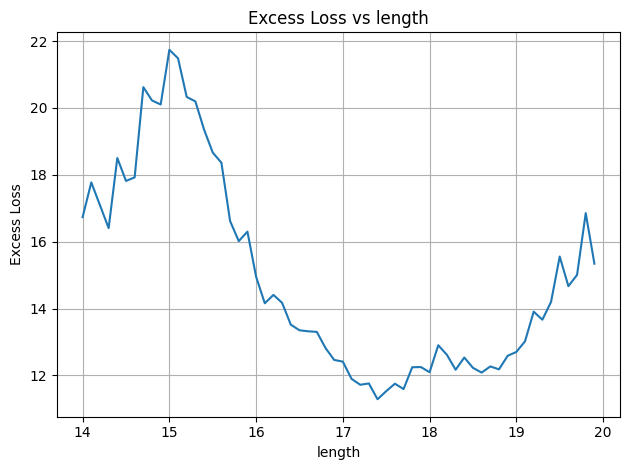

np.float64(17.399999999999988)

In [30]:
wide_lengths = np.arange(14, 20, 0.1)

EL_wide, wide_summary = lu.sweep_param_result(
        sim,
        sweep_params={"lengths": wide_lengths},
        geometry_params={"cell_range": 1},
        geometry_fn=lu.set_eme_group_lengths,
        result_fn=compute_excess_loss,
        result_type=float,
        save_path=f"{wide_device_name}.csv"
    )

lu.plot_metric_1d({"length": wide_lengths}, EL_wide, x_param="length", metric_name="Excess Loss")
best_length_wide = get_best_param(wide_summary, param_col="lengths", default=16.8, col="result")
best_length_wide

100%|██████████| 21/21 [00:02<00:00,  9.25it/s, parameters=wavelength=1.5999999999999979]


✅ Sweep completed. Results saved to: mmi1x2_1550nm_wide_wavelength_sweep.csv


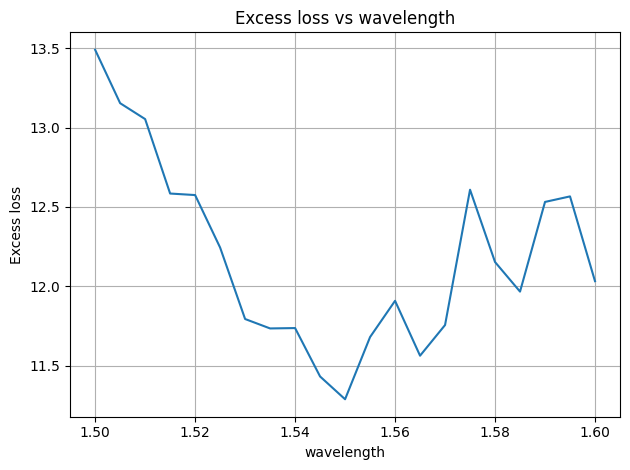

,wavelength,result
0,1.500,13.490596
1,1.505,13.154155
2,1.510,13.053894
3,1.515,12.584704
4,1.520,12.575061
5,1.525,12.244260
6,1.530,11.793829
7,1.535,11.734419
8,1.540,11.736745
9,1.545,11.431627


In [31]:
lu.set_eme_group_lengths(sim, 1, best_length_wide)  # the sweep above left it at its last point

wide_wavelengths = np.arange(1.5, 1.6, 0.005)

EL_wide_wl, wide_wl_summary = lu.sweep_param_result(
        sim,
        sweep_params={"wavelength": wide_wavelengths},
        geometry_fn=set_wavelength_analysis,
        result_fn=compute_excess_loss,
        result_type=float,
        save_path=f"{wide_device_name}_wavelength_sweep.csv"
    )

sim.setemeanalysis("override wavelength", False)

lu.plot_metric_1d({"wavelength": wide_wavelengths}, EL_wide_wl, x_param="wavelength", metric_name="Excess loss")
wide_wl_summary

### Comparison and takeaways

The narrow (`w_mmi = 2.5 µm`) design is essentially flat across the C-band (~0.05–0.19 dB swing,
no minimum in this window). The wide (`w_mmi = 4.5 µm`) design shows a clearly narrower,
oscillatory wavelength response (swings of a couple dB over the same band) — the expected
increase in chromatic sensitivity with device length predicted analytically above. Note: the wide
device's absolute loss floor (~11 dB) is elevated because `n_modes` was kept fixed for a simple,
like-for-like comparison and under-resolves this wider multimode section's guided modes — a
production design at this width would need a larger `n_modes` re-tuned and re-verified, not just
a longer `ln_mmi`.

**Choosing an MMI width when there is no loss-minimizing optimum:** unlike the aperture width or
imaging length, a symmetric 1x2 MMI has no single "best" width — any width can, in principle,
reach near-ideal splitting once matched to the right imaging length. The choice is instead driven
by other constraints, typically in this order:

1. **Mode count**: wide enough to comfortably support the modes needed for the chosen imaging
   order, but not so wide that many extra modes are excited unnecessarily.
2. **Access waveguide spacing**: wide enough that the input/output ports are separated enough for
   low-crosstalk, low-loss routing to neighboring components.
3. **Bandwidth**: narrower (and thus shorter) devices are less chromatically sensitive, as shown
   above — favor the smallest width that still satisfies 1 and 2 if broadband operation matters.
4. **Fabrication tolerance**: very narrow MMIs are more sensitive to CD bias as a fraction of
   width, so foundry design rules may set a practical lower bound.
5. **Footprint**: all else equal, smaller width (and the shorter length it implies) is preferred.

In practice this means picking the *smallest* width that clears constraints 1, 2, and 4, then
re-running the same analytical-estimate → length-sweep → wavelength-sweep flow used above at that
width, rather than searching for a minimum that doesn't exist.